In [23]:
import os
import glob
import numpy as np
import pandas as pd
#import network_fcon as fc
import scipy as sp
from scipy.stats import pearsonr
from scipy.stats import linregress
import seaborn as sns
import matplotlib.pyplot as plt
import re
import seaborn as sns
import statsmodels.formula.api as smf
from netneurotools import datasets, plotting
from nilearn.datasets import fetch_atlas_schaefer_2018

In [114]:
# Set Variables
dataset = 'longglucest_outputmeasures2'
fieldstrength = '3T'
atlas = 'S1000'
bblids = []
sesids = []
nmaps = ["NMDA", "mGluR5", "GABA"]
diag_scores = ["dx_pscat", "hstatus","sex", "age", "race","ethnic"] # ,"axis1_desc1","axis1_stat1"
diag_details = ["axis1_desc1", "axis1_desc2", "axis1_desc3","axis1_desc4","axis1_desc5", "axis1_desc6"]
#subjlist = subjlist[subjlist['fieldstrength'] == fieldstrength]
#subjs = subjlist['BBLID']
pmacs_path = "/Users/pecsok/Desktop/ImageData/PMACS_remote/data/nmaps/analyses/Schaefer2018_1000Parcels_17Networks"
cestlong = pd.read_csv(pmacs_path + '/longform_grpdf_std_' + dataset + '_Schaefer2018_1000Parcels_17Networks.csv')


nmaps_palette = {
    "NMDA": "Blues",   # Replace with actual nmap names and desired palettes
    "GABA": "Greens",
    "mGluR5": "Reds"
    # Add more mappings as needed
}

nmaps_colors = {
    "NMDA": "steelblue",   # Replace with actual nmap names and desired palettes
    "GABA": "seagreen",
    "mGluR5": "indianred"
    # Add more mappings as needed
}

In [115]:
# Import parcel labels and extract network name
schaefer = fetch_atlas_schaefer_2018(n_rois=1000, yeo_networks=17)
labels = schaefer.labels
labels = [label.decode('utf-8') for label in labels]
networks17 = [re.search(r'^[^_]+_[^_]+_([^_]+)_', item).group(1) for item in labels]
networks17 = list(set(networks17))
print(networks17)

cestlong['Networks17']=""
cestlong['Networks7']=""

for network in networks17:
    cestlong.loc[cestlong['Parcel'].str.contains(network), 'Networks17'] = network


['LimbicB', 'ContA', 'DefaultB', 'DorsAttnB', 'TempPar', 'SalVentAttnA', 'SomMotB', 'DorsAttnA', 'ContC', 'DefaultC', 'DefaultA', 'SalVentAttnB', 'VisPeri', 'SomMotA', 'VisCent', 'ContB', 'LimbicA']


In [129]:
# Scrub data

# First, make column "BBLID" that contains the contents of column "Subject" before the _
cestlong['BBLID'] = cestlong['Subject'].str.split('_').str[0]
# Remove duplicate subjs
first_subjects = cestlong.drop_duplicates(subset='BBLID', keep='first')[['BBLID', 'Subject']]
cestlong = cestlong.merge(first_subjects, on=['BBLID', 'Subject'])

print(graph_df.shape)

In [139]:
cestlong

,Subject,Parcel,GluCEST,group,hstatus,NMDA_standard,GABA_standard,mGluR5_standard,SA_standard,Networks17,Networks7,BBLID
0,100522_12003,17Networks_RH_VisCent_Striate_2,NaN,TD/NC,HC,0.946837,2.481264,-0.377612,11,VisCent,,100522
1,102041_12037,17Networks_RH_VisCent_Striate_2,-0.764391,PRO/CHR,PSY,0.946837,2.481264,-0.377612,11,VisCent,,102041
2,111720_11766,17Networks_RH_VisCent_Striate_2,2.214099,TD/NC,HC,0.946837,2.481264,-0.377612,11,VisCent,,111720
3,112061_12261,17Networks_RH_VisCent_Striate_2,1.130654,PRO/CHR,PSY,0.946837,2.481264,-0.377612,11,VisCent,,112061
4,112694_12814,17Networks_RH_VisCent_Striate_2,0.896009,PRO/CHR,PSY,0.946837,2.481264,-0.377612,11,VisCent,,112694
...,...,...,...,...,...,...,...,...,...,...,...,...
5623,96149_12996,17Networks_RH_DefaultA_pCunPCC_12,1.015942,unknown,PSY,1.035005,0.225411,0.970607,557,DefaultA,,96149
5624,96465_12069,17Networks_RH_DefaultA_pCunPCC_12,NaN,TD/NC,HC,1.035005,0.225411,0.970607,557,DefaultA,,96465
5625,96659_12256,17Networks_RH_DefaultA_pCunPCC_12,0.189785,TD/NC,HC,1.035005,0.225411,0.970607,557,DefaultA,,96659
5626,96902_11903,17Networks_RH_DefaultA_pCunPCC_12,-0.191879,TD/NC,HC,1.035005,0.225411,0.970607,557,DefaultA,,96902


32
Blues


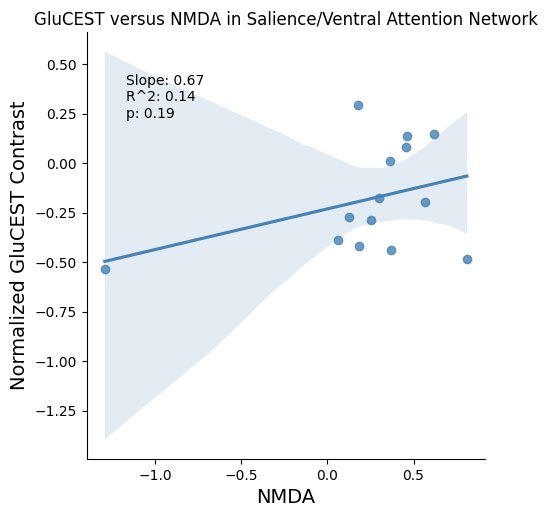

Blues


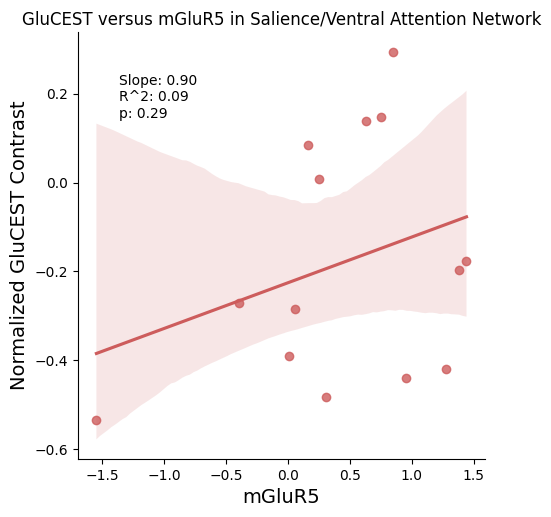

Blues


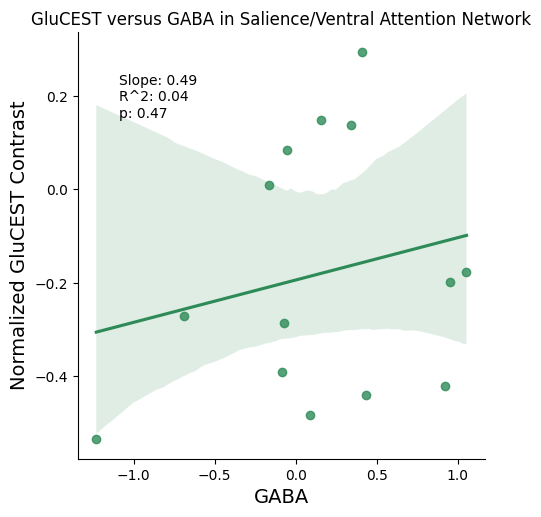

In [143]:
# Plot Salience Network GluCEST vs receptor expression across all participants

# Subset graph_df
graph_df = cestlong[cestlong['Networks17'].str.contains('SalVentAttn')]
graph_df = graph_df[graph_df['hstatus']=="HC"]
subjs = list(set(graph_df['Subject']))
print(len(subjs))
# Reformat for plot
graph_df = (
    graph_df.groupby(['Parcel'])[['GluCEST', 'NMDA_standard', 'GABA_standard', 'mGluR5_standard']]
    .mean()
    .reset_index()
)


for nmap in nmaps:
    nmap_col = nmap + "_standard"
    nmap_color = nmaps_colors.get(nmap)
    print(nmap_palette)
    plot = sns.lmplot(x=nmap_col, y='GluCEST', data=graph_df, scatter_kws={'color': nmap_color}, line_kws={'color': nmap_color}) #, markers=markers_list, 
    plt.xlabel(nmap, fontsize=14)
    plt.ylabel("Normalized GluCEST Contrast",fontsize=14)
    plt.title('GluCEST versus ' + nmap + ' in Salience/Ventral Attention Network')

    slope, intercept, r_value, p_value, std_err = linregress(graph_df['GluCEST'], graph_df[nmap_col])    
    plt.text(0.1, 0.8, f'\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes, fontsize=10)
    plt.show()  


Blues


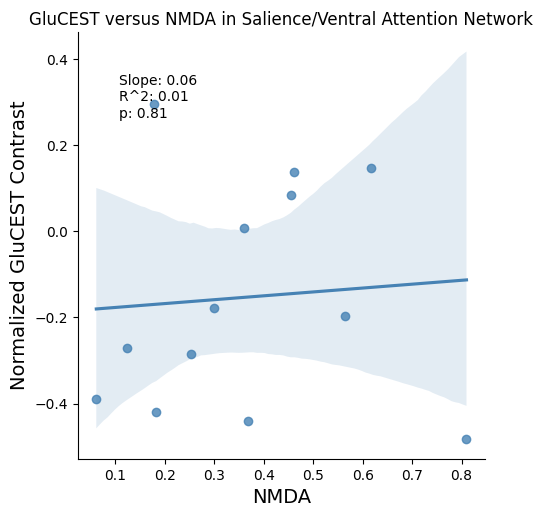

In [131]:
# Plot Salience Network GluCEST after excluding outlier in NMDA

# Subset graph_df to exclude outlier. Otherwise, df is same as chunk above
graph_df = graph_df[graph_df['NMDA_standard'] >= -1]

# Make plot
nmap = "NMDA"
nmap_col = nmap + "_standard"
nmap_color = nmaps_colors.get(nmap)
print(nmap_palette)
plot = sns.lmplot(x=nmap_col, y='GluCEST', data=graph_df, scatter_kws={'color': nmap_color}, line_kws={'color': nmap_color}) #, markers=markers_list, 
plt.xlabel(nmap, fontsize=14)
plt.ylabel("Normalized GluCEST Contrast",fontsize=14)
plt.title('GluCEST versus ' + nmap + ' in Salience/Ventral Attention Network')

slope, intercept, r_value, p_value, std_err = linregress(graph_df['GluCEST'], graph_df[nmap_col])    
plt.text(0.1, 0.8, f'\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes, fontsize=10)
plt.show()  


                                  Parcel hstatus   GluCEST  NMDA_standard  \
0     17Networks_RH_SalVentAttnA_FrMed_1      HC -0.262159       0.181644   
1     17Networks_RH_SalVentAttnA_FrMed_1     PSY -0.324713       0.181644   
2     17Networks_RH_SalVentAttnA_FrMed_2      HC -0.342305       0.367810   
3     17Networks_RH_SalVentAttnA_FrMed_2     PSY -0.465313       0.367810   
4     17Networks_RH_SalVentAttnA_FrMed_3      HC  0.163007       0.461150   
5     17Networks_RH_SalVentAttnA_FrMed_3     PSY  0.111582       0.461150   
6     17Networks_RH_SalVentAttnA_FrMed_4      HC  0.278305       0.179060   
7     17Networks_RH_SalVentAttnA_FrMed_4     PSY  0.191857       0.179060   
8     17Networks_RH_SalVentAttnA_FrMed_5      HC  0.004421       0.454223   
9     17Networks_RH_SalVentAttnA_FrMed_5     PSY  0.038455       0.454223   
10    17Networks_RH_SalVentAttnA_FrMed_6      HC -0.294346       0.809865   
11    17Networks_RH_SalVentAttnA_FrMed_6     PSY -0.312514       0.809865   

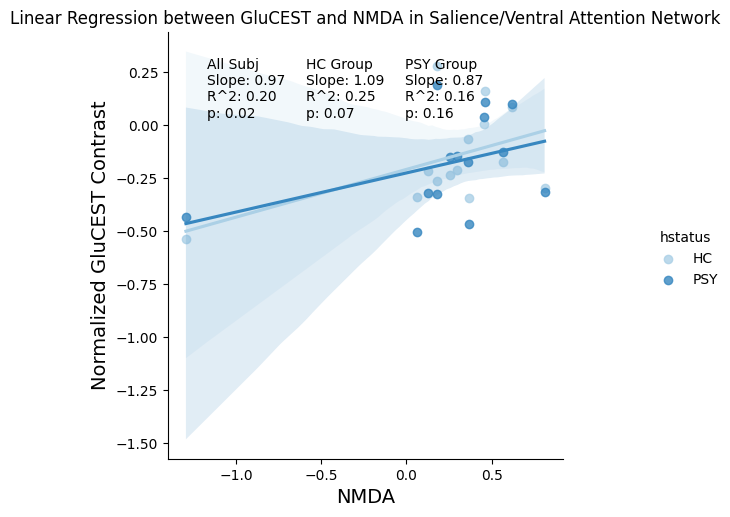

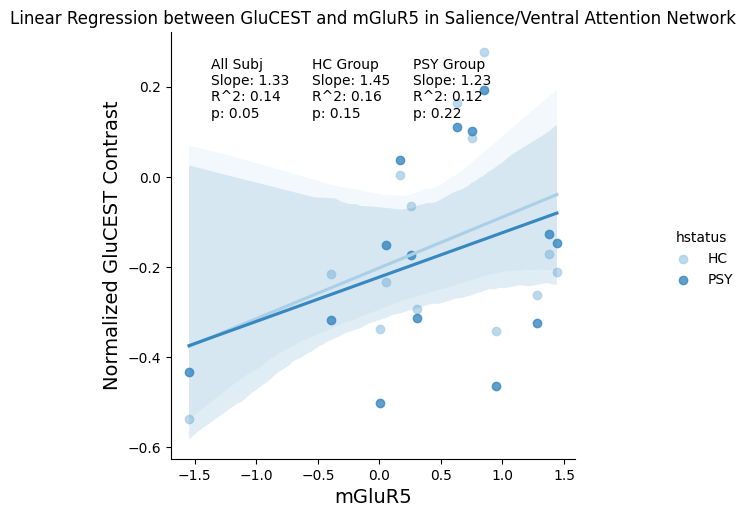

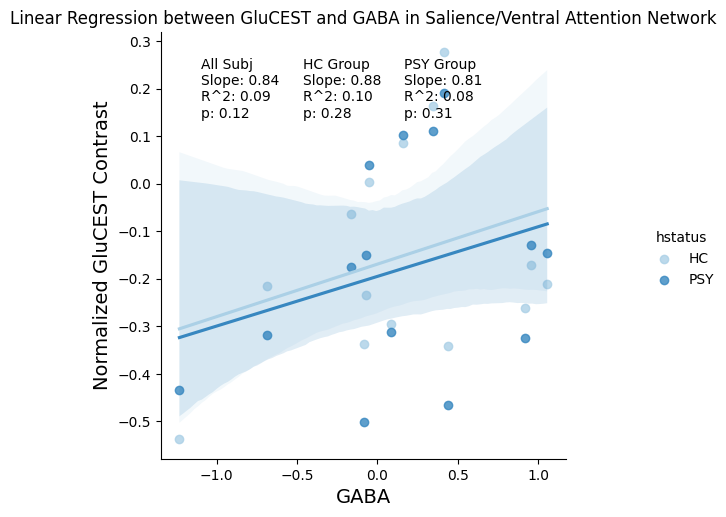

In [97]:
# Subset graph_df
graph_df = cestlong[cestlong['Networks17'].str.contains('SalVentAttn')]
graph_df = (
    graph_df.groupby(['Parcel', 'hstatus'])[['GluCEST', 'NMDA_standard', 'GABA_standard', 'mGluR5_standard']]
    .mean()
    .reset_index()
)
print(graph_df)

for nmap in nmaps:
    nmap_col = nmap + "_standard"
    plot = sns.lmplot(x=nmap_col, y='GluCEST', hue='hstatus', data=graph_df, palette=palette) #, markers=markers_list, 

    plt.xlabel(nmap, fontsize=14)
    plt.ylabel("Normalized GluCEST Contrast",fontsize=14)
    plt.title('Linear Regression between GluCEST and ' + nmap + ' in Salience/Ventral Attention Network')

    slope, intercept, r_value, p_value, std_err = linregress(graph_df['GluCEST'], graph_df[nmap_col])    
    plt.text(0.1, 0.8, f'All Subj\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes, fontsize=10)
    slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['hstatus'] == 'HC', 'GluCEST'], graph_df.loc[graph_df['hstatus'] == 'HC', nmap_col])
    plt.text(0.35, 0.8, f'HC Group\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes, fontsize=10)
    slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['hstatus'] == 'PSY', 'GluCEST'], graph_df.loc[graph_df['hstatus'] == 'PSY', nmap_col])
    plt.text(0.6, 0.8, f'PSY Group\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes, fontsize=10)

    plt.show()  
